<a href="https://colab.research.google.com/github/LukeRDuob/AI-Labsheets/blob/main/Coursework_sectionA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## AMA Coursework


In [31]:
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
import torch as t
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


### Section A

(Q1) Load the CIFAR-10 dataset in Google Colab. (4 marks)
Then use python to display:

1. The number of training samples.
2. The number of test samples.
3. The list of class names contained in CIFAR-10.


In [38]:
# Load dataset
train_dataset = CIFAR10('./data', train=True, download=True)
test_dataset = CIFAR10('./data', train=False, download=True)

# Output stats
print(f'Number of training images: {len(train_dataset)}')
print(f'Number of test images: {len(test_dataset)}')
print(f'Classes: {train_dataset.classes}')


Number of training images: 50000
Number of test images: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


(Q2) Visualise a grid of 12 sample images and labels. (4 marks)
Use matplotlib to display a 3X4 grid of sample images with their corresponding class names.
You should display unprocessed raw images, and include class name text below each
image. One example result looks like (You should use different images):

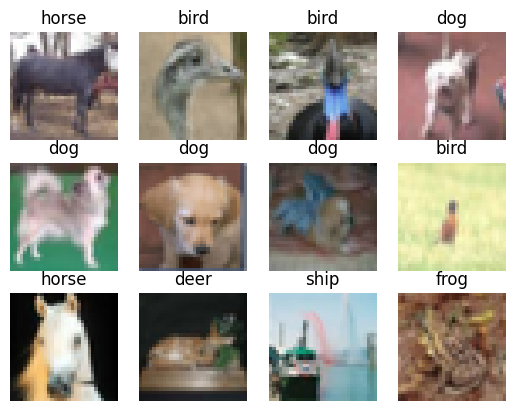

In [39]:
# Select 12 random samples
indexes = np.random.randint(0, len(train_dataset), size=12)
classes = train_dataset.classes

# Plot images
fig, axes = plt.subplots(3, 4)

# Plot each image in the grid
for ax, i in zip(axes.flatten(), indexes):
    image, label = train_dataset[i]
    ax.set_axis_off()
    ax.imshow(image)
    ax.set_title(classes[label])
plt.show()




(Q3) Apply data augmentation and display (8 marks)

Create a data transformation pipeline using either torchvision.transforms or albumentations,
ensuring that it includes image normalisation, conversion to tensors, and four distinct
augmentation operations. After defining the transformation pipeline, you should display each
raw image alongside its aforementioned four augmented versions produced by the different
augmentation methods, with figures clearly showing the effects of each transformation. Then
implement a data loader. Create the DataLoaders for the CIFAR-10 dataset using torch.utils.data.DataLoader. The training DataLoader, named train_loader, should use a
batch size of 16, enable shuffling of the data, and set num_workers to 2. The test
DataLoader, named test_loader, should use a batch size of 1, with shuffling disabled, and
also set num_workers to 2.


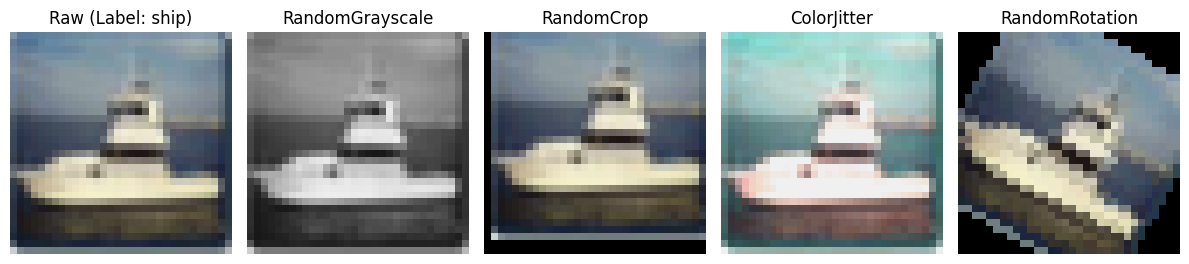

In [55]:
def tensor_to_image_np(tensor):
    """Converts a normalized tensor (C,H,W) back to a plottable numpy array (H,W,C)."""
    mean = np.array([0.5,0.5,0.5])[:, None, None]
    std = np.array([0.5,0.5,0.5])[:, None, None]
    arr = tensor.cpu().numpy()
    img = (arr * std + mean).clip(0,1)
    img = np.transpose(img, (1,2,0))
    return img


# Define transformations
transform_choices = {
    'Standard': transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
      ]),

    'RandomGrayscale': transforms.Compose([
        transforms.RandomGrayscale(p=1.0),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
      ]),

    'RandomCrop': transforms.Compose([
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
      ]),

    'ColorJitter': transforms.Compose([
        transforms.RandomApply([
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1)],
            p=0.8
        ),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
      ]),

    'RandomRotation': transforms.Compose([
        transforms.RandomRotation(degrees=30),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
      ]),

    'Complete': transforms.Compose([
        transforms.RandomGrayscale(p=0.2),
        transforms.RandomCrop(32, padding=4),
        transforms.RandomApply([
            transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.2, hue=0.1)],
            p=0.8
        ),
        transforms.RandomRotation(degrees=30),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
  }

raw_dataset = CIFAR10('./data', train=True, download=True)  # No transform → PIL
classes = raw_dataset.classes

# Select a random sample
index = np.random.randint(0, len(raw_dataset))
classes = raw_dataset.classes

# Get image and label
pil_img, label = raw_dataset[index]

# Plot image transforms
fig, axes = plt.subplots(1, 5, figsize=(12,4))

# Plot each image in the grid
for ax, (key, chosen_transform) in zip(axes.flatten(), transform_choices.items()):
    ax.set_axis_off()
    if key == 'Standard':
        # Raw image shown
        display_image = pil_img
        ax.set_title(f'Raw (Label: {classes[label]})')
    else:
        # Apply transform
        new_img = chosen_transform(pil_img)
        display_image = tensor_to_image_np(new_img)
        ax.set_title(key)
    ax.imshow(display_image)

plt.tight_layout()
plt.show()


# Get training and testing datasets (using standard transform)
train_dataset_with_transform = CIFAR10('./data', train=True, download=True, transform=transform_choices['Complete'])
test_dataset_with_transform = CIFAR10('./data', train=False, download=True, transform=transform_choices['Complete'])


# Define loaders
train_loader = DataLoader(train_dataset_with_transform, batch_size=16, num_workers=2, shuffle=False)
test_loader = DataLoader(test_dataset_with_transform, batch_size=1, num_workers=2, shuffle=False)

# Extract images and labels
# train_imgs, train_labels = [], []
# test_imgs, test_labels = [], []

# # Training data
# for tr_img, tr_label in train_loader:
#     train_imgs.append(tr_img)
#     train_labels.append(tr_label)

# # Testing data
# for te_img, te_label in test_loader:
#     test_imgs.append(te_img)
#     test_labels.append(te_label)


